Red neuronal para 10 gatos y perros

In [ ]:
import numpy as np
import os
from PIL import Image
from google.colab import files


In [ ]:
#Cargamos nuestro set de imagenes
with zipfile.ZipFile("perrosygatos10.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
#Verificamos

os.listdir("dataset")

os.listdir("dataset/perrosygatos10")

['998.jpg',
 '9989.jpg',
 '999.jpg',
 '9973.jpg',
 '9971.jpg',
 '9959.jpg',
 '9999.jpg',
 '9990.jpg',
 '9988.jpg',
 '9981.jpg']

In [ ]:
#Revisamos el tamaño que tienen las imagenes
ruta = "dataset/perrosygatos10"

archivos = os.listdir(ruta)

for archivo in archivos:

    ruta_img = os.path.join(ruta, archivo)

    img = Image.open(ruta_img)

    print(archivo, img.size)

998.jpg (494, 500)
9989.jpg (500, 500)
999.jpg (300, 300)
9973.jpg (343, 477)
9971.jpg (312, 329)
9959.jpg (500, 499)
9999.jpg (500, 500)
9990.jpg (479, 500)
9988.jpg (500, 362)
9981.jpg (373, 500)


In [ ]:
#Ahora tenemos que convertirlas a vectores
x=[]
for img in imagenes:
  img_array= np.array(img)
   #Normalizamos
  img_array=img_array/255
   # flatten
  img_array = img_array.reshape(-1)
  x.append(img_array)

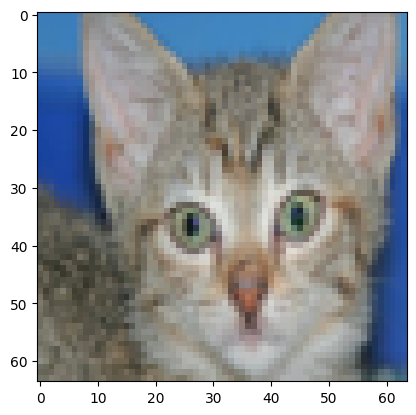

In [ ]:
import matplotlib.pyplot as plt
#Visualizamos una imagen
index=8
plt.imshow(imagenes[index])
plt.show()

In [ ]:
x = np.array(x)

print(x.shape)

(10, 12288)


In [ ]:
#etiquetamos o algo asi solo se me ocurrio hacerlo asi
perros = ["998", "9959", "9971", "9973", "9990"]
gatos  = ["999", "9981", "9988", "9989", "9999"]

Y=[]
for archivo in archivos:
  nombre=archivo.split('.')[0]

  if nombre in gatos:
    Y.append(1)
  elif nombre in perros:
    Y.append(0)
  else:
     print("No clasificado:", archivo)

Y = np.array(Y).reshape(1, -1)

print(Y)
print(Y.shape)




[[0 1 1 0 0 0 1 0 1 1]]
(1, 10)


In [ ]:
#Se debe mezclar antes de dividir
np.random.seed(1)
perm = np.random.permutation(x.shape[1])

x = x[:, perm]
Y = Y[:, perm]

print(Y)

[[1 1 1 0 0 0 1 0 1 0]]


In [ ]:
# Dividimos en entrenamiento y prueba

X_train = x[:, :8]
Y_train = Y[:, :8]

X_test = x[:, 8:]
Y_test = Y[:, 8:]

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: (12288, 8)
Y_train: (1, 8)
X_test: (12288, 2)
Y_test: (1, 2)


In [ ]:
#definimos variables
n_x=X_train.shape[0]
print(n_x)
w=np.zeros((n_x,1))
print(w)
b=0
z=np.dot(w.T,X_train)+b
print(z)

12288
[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
[[0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
# Ahora la funcion de activacion
def sigmoid(z):
  return 1/(1+np.exp(-z))
a= sigmoid(z)
print(a)

[[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]]


In [ ]:
#Esta definicion hace que se vuelva erronea el valor numerico de J, entonces voy a usar a
#y = (a > 0.5).astype(int)
#print(y)

[[0 0 0 0 0 0 0 0]]


In [ ]:
# entonces podemos construir la fucion de costos

m= X_train.shape[1]

J=- (1/m)*np.sum(Y_train*np.log(a)+(1-Y_train)*np.log(1-a))
print(J)

0.6931471805599453


In [ ]:
#Ahora hacemos la gradiente descendiente
alpha=0.001
dw=(1/m)*np.dot(X_train,(a-Y_train).T)
db=(1/m)*np.sum(a-Y_train)
w=w-alpha*dw
b=b-alpha*db
print(w)
print(b)

[[5.12254902e-05]
 [3.52941176e-05]
 [4.09313725e-05]
 ...
 [2.00980392e-05]
 [1.93627451e-05]
 [3.23529412e-05]]
0.0


In [ ]:
#Ya que ya vi como funciona una vez ahora hacemos que se repita
for i in range(300):
  z=np.dot(w.T,X_train)+b
  a=sigmoid(z)
  J=- (1/m)*np.sum(Y_train*np.log(a)+(1-Y_train)*np.log(1-a))
  dw=(1/m)*np.dot(X_train,(a-Y_train).T)
  db=(1/m)*np.sum(a-Y_train)
  w=w-alpha*dw
  b=b-alpha*db

  if i % 100==0:
    print(i,J)


0 0.01028584576801738
100 0.009809601688672204
200 0.009375274888284466


In [ ]:
#Calculamos la prediccion para entrenamiento, no se si esto esta bien
z_train = np.dot(w.T, X_train) + b
a_train = sigmoid(z_train)

pred_train = (a_train >= 0.5).astype(int)

print("Predicciones train:", pred_train)
print("Valores reales train:", Y_train)

accuracy_train = np.mean(pred_train == Y_train) * 100
print("Accuracy train:", accuracy_train, "%")

Predicciones train: [[1 1 1 0 0 0 1 0]]
Valores reales train: [[1 1 1 0 0 0 1 0]]
Accuracy train: 100.0 %


In [ ]:
#Ahora veamos el test
z_test = np.dot(w.T, X_test) + b
a_test = sigmoid(z_test)
pred_test = (a_test >= 0.5).astype(int)

print("Predicciones test:", pred_test)
print("Valores reales test:", Y_test)

accuracy_test = np.mean(pred_test == Y_test) * 100
print("Accuracy test:", accuracy_test, "%")

Predicciones test: [[0 1]]
Valores reales test: [[1 0]]
Accuracy test: 0.0 %


Ahora tomo los datos de la carpeta desde Kaggle, ahora tomando 20 y 20, utilizando32 para entrenar y 8 para test

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"estefaniahernndez","key":"fd87ce324462e55a12b1f2baec810cbe"}'}

In [ ]:
#Creamos carpeta
!mkdir -p ~/.kaggle
#Utilizamo llave
!cp kaggle.json ~/.kaggle/
#Damos permiso
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#Descargamos el dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "bhavikjikadara/dog-and-cat-classification-dataset"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
Path to dataset files: /kaggle/input/dog-and-cat-classification-dataset


In [ ]:
import numpy as np
import os
from PIL import Image
import random


In [ ]:
#Revisamos en que parte del directorio se encuentra

print(os.listdir(path))


['PetImages']


In [ ]:
#Ahora damos la ruta
ruta_base = os.path.join(path, "PetImages")

print(os.listdir(ruta_base))

['Dog', 'Cat']


In [ ]:
#Vemos cuantos elementos tiene
ruta_gatos = os.path.join(ruta_base, "Cat")
ruta_perros = os.path.join(ruta_base, "Dog")
print(len(os.listdir(ruta_gatos)))
print(len(os.listdir(ruta_perros)))

12499
12499


In [ ]:
#De cada uno de estos sets tomamos 20 imagenes de cada tipo
np.random.seed(1)
random.seed(1)

gatos = random.sample(os.listdir(ruta_gatos),50)
perros = random.sample(os.listdir(ruta_perros), 50)




In [ ]:
#Aqui ya vamos a hacer muchas cosas de una, vamos a convertir a matrices de pixel, e
#standarizar a 64 pixeles, hacer ahora una matrz con las imagenes, etc
X=[]
Y=[]
#vamos primero con los perros
for archivo in perros:
  ruta_img = os.path.join(ruta_perros, archivo)
  img = Image.open(ruta_img)
  img = img.resize((64, 64))
  img_array = np.array(img)
  img_array = img_array / 255
  img_array = img_array.reshape(-1)
  X.append(img_array)
  Y.append(0)

#Ahora gatos
for archivo in gatos:
  ruta_img = os.path.join(ruta_gatos, archivo)
  img = Image.open(ruta_img)
  img = img.resize((64, 64))
  img_array = np.array(img)
  img_array = img_array / 255
  img_array = img_array.reshape(-1)
  X.append(img_array)
  Y.append(1)

In [ ]:
# Lo volvemos un array

X= np.array(X)

print(X.shape)

(100, 12288)


In [ ]:

X = X.T

print(X.shape)

# Convert Y to array and reshape to (1, samples)
Y = np.array(Y).reshape(1,-1)

# Mezclamos
np.random.seed(1)

# Generate permutation based on the number of samples (X.shape[1] after transpose)
perm = np.random.permutation(X.shape[1])

X = X[:, perm]
Y = Y[:, perm]

print(X.shape)
print(Y.shape)

(12288, 100)
(12288, 100)
(1, 100)


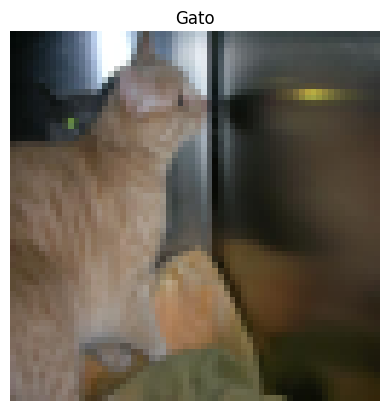

In [ ]:
#Graficamos para ver si esta random y en 64 pixeles

import matplotlib.pyplot as plt

index = 30

img = X[:, index].reshape(64,64,3)

plt.imshow(img)

if Y[0, index] == 1:
    plt.title("Gato")
else:
    plt.title("Perro")

plt.axis("off")
plt.show()

In [ ]:
# Dividimos en entrenamiento y prueba

X_train = X[:, :80]
Y_train = Y[:, :80]

X_test = X[:, 80:]
Y_test = Y[:, 80:]

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: (12288, 80)
Y_train: (1, 80)
X_test: (12288, 20)
Y_test: (1, 20)


In [ ]:
#definimos variables
n_x=X_train.shape[0]
print(n_x)
w=np.zeros((n_x,1))
print(w)
b=0
z=np.dot(w.T,X_train)+b
print(z)

12288
[[0.]
 [0.]
 [0.]
 ...
 [0.]
 [0.]
 [0.]]
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0.]]


In [ ]:
# Ahora la funcion de activacion
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [ ]:
#Ahoraaa definimos variables que ocuparemos para la funcion de costos
m= X_train.shape[1]
alpha=0.001
#Aplicamos el ciclo again
for i in range(225):
  z=np.dot(w.T,X_train)+b
  a=sigmoid(z)
  J=- (1/m)*np.sum(Y_train*np.log(a)+(1-Y_train)*np.log(1-a))
  dw=(1/m)*np.dot(X_train,(a-Y_train).T)
  db=(1/m)*np.sum(a-Y_train)
  w=w-alpha*dw
  b=b-alpha*db

  if i % 50==0:
    print(i,J)



0 0.6931471805599454
50 0.6073999494720171
100 0.5530244668563752
150 0.5111642212450154
200 0.4769803297812524


In [ ]:
#Calculamos la prediccion para entrenamiento, no se si esto esta bien
z_train = np.dot(w.T, X_train) + b
a_train = sigmoid(z_train)

pred_train = (a_train >= 0.5).astype(int)

print("Predicciones train:", pred_train)
print("Valores reales train:", Y_train)

accuracy_train = np.mean(pred_train == Y_train) * 100
print("Accuracy train:", accuracy_train, "%")

Predicciones train: [[1 1 0 1 1 0 0 1 0 1 1 0 0 1 1 0 0 0 1 0 0 1 1 1 0 1 1 0 0 1 1 1 0 1 1 0
  0 1 1 0 1 1 1 0 1 0 0 1 0 1 0 1 0 0 1 0 0 1 0 1 0 1 1 0 0 1 0 1 0 1 1 0
  1 1 0 1 0 0 0 0]]
Valores reales train: [[1 1 0 1 1 0 0 1 1 1 1 0 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 1 1 0
  0 1 0 0 1 1 1 0 1 0 0 1 0 1 0 1 0 0 1 0 0 1 0 1 0 1 1 0 0 1 0 1 0 1 1 0
  1 1 0 1 0 1 1 0]]
Accuracy train: 90.0 %


In [ ]:
comparacion = pred_train == Y_train

print("Comparación:", comparacion.astype(int))
print("Aciertos:", np.sum(comparacion))
print("Total:", Y_train.size)
print("Accuracy real:", np.sum(comparacion) / Y_train.size * 100)

Comparación: [[1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1 1 1
  1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
  1 1 1 1 1 0 0 1]]
Aciertos: 72
Total: 80
Accuracy real: 90.0


In [ ]:
# Predicción test

z_test = np.dot(w.T, X_test) + b
a_test = sigmoid(z_test)

pred_test = (a_test >= 0.5).astype(int)

accuracy_test = np.mean(pred_test == Y_test) * 100
print("Predicciones test:", pred_test)
print("Valores reales test:", Y_test)
print("Accuracy test:", accuracy_test, "%")

Predicciones test: [[0 0 0 0 1 0 1 1 0 0 0 1 1 0 0 0 0 1 0 0]]
Valores reales test: [[0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 1 0 1 0 0]]
Accuracy test: 55.00000000000001 %


In [ ]:
print("Accuracy train:", accuracy_train, "%")
print("Accuracy test:", accuracy_test, "%")

Accuracy train: 90.0 %
Accuracy test: 55.00000000000001 %


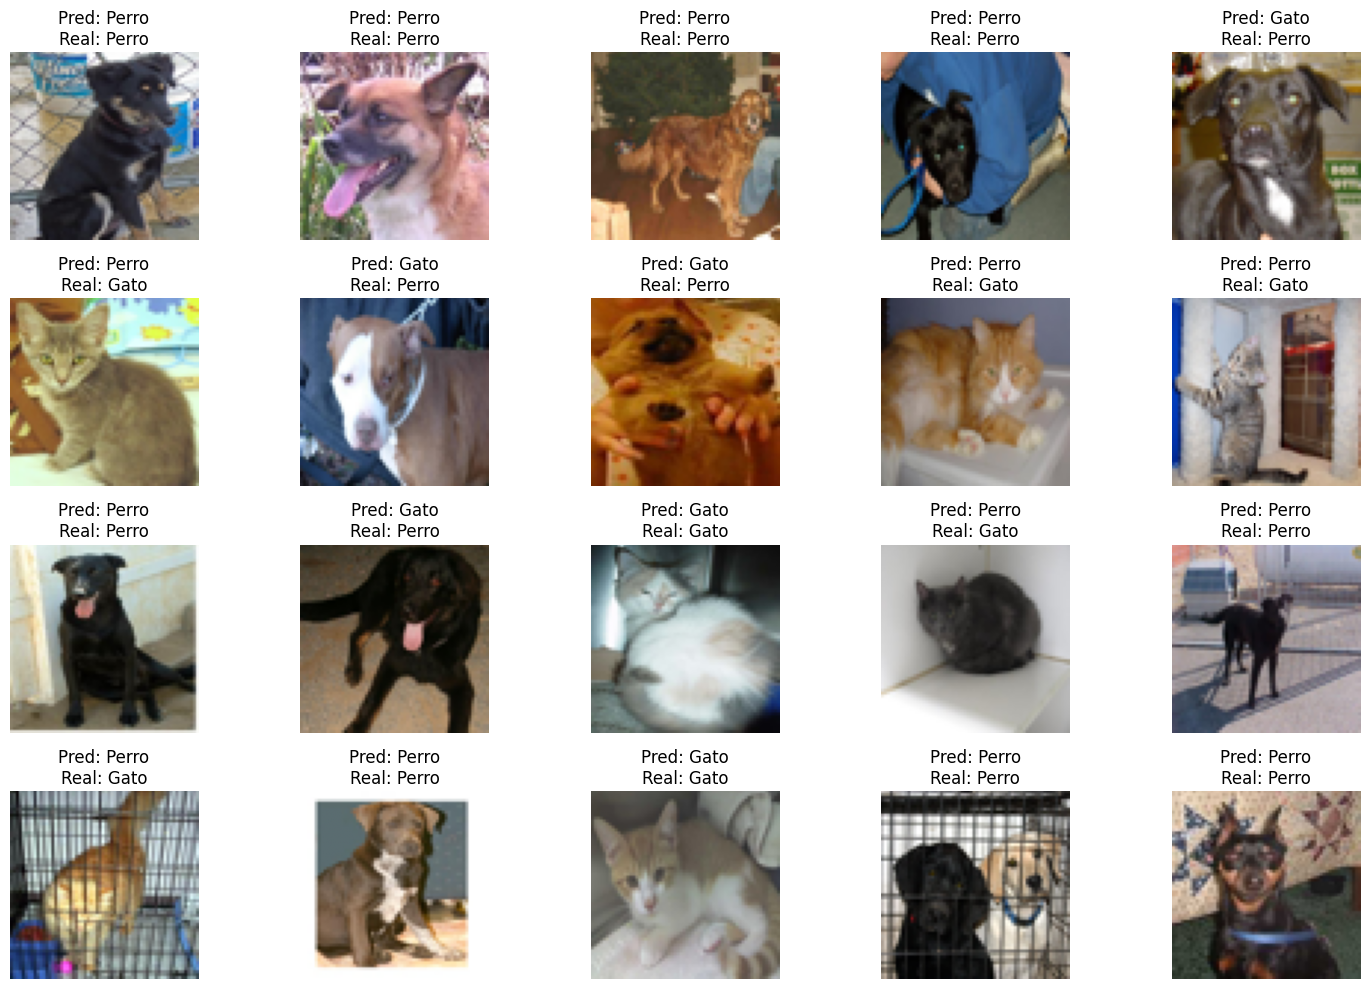

In [ ]:
# Graficarlo
import matplotlib.pyplot as plt

# Calculamos probabilidades y predicciones
z_test = np.dot(w.T, X_test) + b
a_test = sigmoid(z_test)

pred_test = (a_test >= 0.5).astype(int)

# Graficamos todas las imágenes de test

num_imagenes = X_test.shape[1]

plt.figure(figsize=(15,10))

for i in range(num_imagenes):

    img = X_test[:, i].reshape(64,64,3)

    plt.subplot(4,5,i+1)

    plt.imshow(img)

    pred = "Gato" if pred_test[0,i] == 1 else "Perro"
    real = "Gato" if Y_test[0,i] == 1 else "Perro"

    plt.title(f"Pred: {pred}\nReal: {real}")

    plt.axis("off")

plt.tight_layout()
plt.show()

Vamos a inentar a 2 neuronas

In [ ]:
#Descargamos el dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "bhavikjikadara/dog-and-cat-classification-dataset"
)

print("Path to dataset files:", path)

100%|██████████| 775M/775M [00:29<00:00, 27.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/bhavikjikadara/dog-and-cat-classification-dataset/versions/1


In [ ]:
import numpy as np
import os
from PIL import Image
import random

In [ ]:
#Vemos cuantos elementos tiene
ruta_gatos = os.path.join(ruta_base, "Cat")
ruta_perros = os.path.join(ruta_base, "Dog")
print(len(os.listdir(ruta_gatos)))
print(len(os.listdir(ruta_perros)))

NameError: name 'ruta_base' is not defined

In [ ]:
#De cada uno de estos sets tomamos 20 imagenes de cada tipo
np.random.seed(1)
random.seed(1)

gatos = random.sample(os.listdir(ruta_gatos),250)
perros = random.sample(os.listdir(ruta_perros), 250)


NameError: name 'ruta_gatos' is not defined

In [ ]:
#Aqui ya vamos a hacer muchas cosas de una, vamos a convertir a matrices de pixel, e
#standarizar a 64 pixeles, hacer ahora una matrz con las imagenes, etc
X=[]
Y=[]
#vamos primero con los perros
for archivo in perros:
  ruta_img = os.path.join(ruta_perros, archivo)
  img = Image.open(ruta_img)
  # Convert image to RGB to ensure consistent channel count
  img = img.convert('RGB')
  img = img.resize((64, 64))
  img_array = np.array(img)
  img_array = img_array / 255
  img_array = img_array.reshape(-1)
  X.append(img_array)
  Y.append(0)

#Ahora gatos
for archivo in gatos:
  ruta_img = os.path.join(ruta_gatos, archivo)
  img = Image.open(ruta_img)
  # Convert image to RGB to ensure consistent channel count
  img = img.convert('RGB')
  img = img.resize((64, 64))
  img_array = np.array(img)
  img_array = img_array / 255
  img_array = img_array.reshape(-1)
  X.append(img_array)
  Y.append(1)

In [ ]:
X= np.array(X)

print(X.shape)
X = X.T

print(X.shape)

# Convert Y to array and reshape to (1, samples)
Y = np.array(Y).reshape(1,-1)

# Mezclamos
np.random.seed(1)

# Generate permutation based on the number of samples (X.shape[1] after transpose)
perm = np.random.permutation(X.shape[1])

X = X[:, perm]
Y = Y[:, perm]

print(X.shape)
print(Y.shape)

(500, 12288)
(12288, 500)
(12288, 500)
(1, 500)


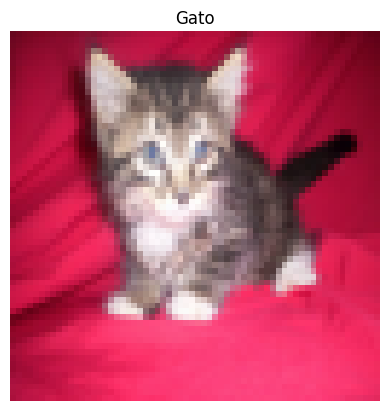

In [ ]:
#Graficamos para ver si esta random y en 64 pixeles

import matplotlib.pyplot as plt

index = 10

img = X[:, index].reshape(64,64,3)

plt.imshow(img)

if Y[0, index] == 1:
    plt.title("Gato")
else:
    plt.title("Perro")

plt.axis("off")
plt.show()

In [ ]:
# Dividimos en entrenamiento y prueba

X_train = X[:, :400]
Y_train = Y[:, :400]

X_test = X[:, 400:]
Y_test = Y[:, 400:]

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: (12288, 400)
Y_train: (1, 400)
X_test: (12288, 100)
Y_test: (1, 100)


In [ ]:
#Ahora debemos definir las variables
n_x=X_train.shape[0] #numero de pixeles
print(n_x)
n_h=2 #numero de neuronas
n_y=1 #numero de salidas
w1=np.random.randn(n_h,n_x)*0.01
print(w1)
w2=np.random.randn(n_y,n_h)*0.01
print(w2)
b1=np.zeros((n_h,1))
print(b1)
b2=np.zeros((n_y,1))
print(b2)


12288
[[-2.32879307e-02 -1.32272185e-03 -5.20694867e-03 ...  2.69811770e-02
   6.60934354e-03  1.07988803e-03]
 [-2.65639434e-03 -1.35048753e-03 -9.60103451e-03 ...  4.62271387e-05
  -2.91196790e-03 -8.12571233e-04]]
[[ 0.0165074  -0.00574904]]
[[0.]
 [0.]]
[[0.]]


In [ ]:
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

def relu(Z):
    return np.maximum(0, Z)

In [ ]:
#Ahoraaa definimos variables que ocuparemos para la funcion de costos
m= X_train.shape[1]
alpha=0.005
#Aplicamos el ciclo again
for i in range(5000):
  Z1 = np.dot(w1, X_train) + b1
  A1 = relu(Z1)
  Z2 = np.dot(w2, A1) + b2
  A2 = sigmoid(Z2)
  J=- (1/m)*np.sum(Y_train*np.log(A2)+(1-Y_train)*np.log(1-A2))

  dZ2 = A2 - Y_train
  dW2 = (1/m) * np.dot(dZ2, A1.T)
  db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

  dZ1 = np.dot(w2.T, dZ2) * (A1 > 0)
  dW1 = (1/m) * np.dot(dZ1, X_train.T)
  db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
  w1 = w1 - alpha * dW1
  b1 = b1 - alpha * db1
  w2 = w2 - alpha * dW2
  b2 = b2 - alpha * db2

  if i % 100==0:
    print(i,J)



0 0.6930988804555704
100 0.6930538757194381
200 0.6930062286132349
300 0.6929357832471337
400 0.6928271618230569
500 0.6926569894931177
600 0.6924128722757407
700 0.6920575990509832
800 0.6914985607513552
900 0.6906379757004222
1000 0.6892877422493682
1100 0.6873179783569978
1200 0.6844238993809537
1300 0.6805246993489996
1400 0.675603679151713
1500 0.6697552427038517
1600 0.6629340564296854
1700 0.655198138486019
1800 0.6464349819606655
1900 0.6369099651035525
2000 0.6265692339446727
2100 0.614044751865467
2200 0.6014053762035546
2300 0.5877537612511409
2400 0.5765178466266444
2500 0.564152593761438
2600 0.558196234941168
2700 0.5553545731194499
2800 0.5516088294094413
2900 0.5253612223683064
3000 0.4915275249120205
3100 0.5389726086514111
3200 0.4985103231438467
3300 0.48833642076965034
3400 0.49445168704834574
3500 0.49925009227918893
3600 0.5224478168760599
3700 0.5051703514376077
3800 0.47759637614308886
3900 0.438210036542871
4000 0.4750393293897178
4100 0.42895210224933933
4200 

In [ ]:
#Calculamos prediccion para entrenamiento
Z1 = np.dot(w1, X_train) + b1
A1 = relu(Z1)

Z2 = np.dot(w2, A1) + b2
A2 = sigmoid(Z2)

pred_train = (A2 > 0.5)



accuracy_train = np.mean(pred_train == Y_train) * 100
print("Accuracy train:", accuracy_train, "%")



Accuracy train: 91.0 %


In [ ]:
#Calculamos prediccion para probarlo
Z1 = np.dot(w1, X_test) + b1
A1 = relu(Z1)

Z2 = np.dot(w2, A1) + b2
A2 = sigmoid(Z2)

pred_test = (A2 > 0.5)



accuracy_test = np.mean(pred_test == Y_test) * 100
print("Accuracy test:", accuracy_test, "%")

NameError: name 'np' is not defined